# Stable and variable morphology visualized — fixed version

This version removes hidden kernel-state dependencies and makes the notebook reproducible from top to bottom.

What was fixed:
- avoids a hard-coded Windows-only path by allowing `DATA_DIR` to be set explicitly
- loads tables in a reusable way
- defines the missing `shorten_intensity_label()` helper
- uses pre-existing cluster columns directly (`cluster_agg_k5` for 1462 and `cluster_agg_k2` for 1476)
- does **not** perform clustering inside this notebook
- writes output files relative to `DATA_DIR`


In [1]:

from pathlib import Path
import pandas as pd

# --- Choose where the CSV/XLSX files live ------------------------------------
# Option 1: set the folder explicitly on your machine
DATA_DIR = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML")


if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")

files = sorted([p for p in DATA_DIR.iterdir() if p.is_file()])
print(f"Using DATA_DIR: {DATA_DIR}")
for f in files:
    print(f.name)


Using DATA_DIR: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML
clearing metadata for ML.ipynb
combined_clustered_data_1462_k5.csv
combined_clustered_data_1476_k2.csv


In [2]:

from pathlib import Path
import pandas as pd

tables = {}

for f in sorted(DATA_DIR.iterdir()):
    if not f.is_file():
        continue

    suffix = f.suffix.lower()

    try:
        if suffix == ".csv":
            tables[f.stem] = pd.read_csv(f)
            print(f"Loaded CSV:  {f.name} -> {tables[f.stem].shape}")

        elif suffix in [".xlsx", ".xls"]:
            tables[f.stem] = pd.read_excel(f)
            print(f"Loaded Excel: {f.name} -> {tables[f.stem].shape}")

    except Exception as e:
        print(f"Could not load {f.name}: {e}")

if not tables:
    raise RuntimeError(
        "No tables were loaded. Put the clustered CSV/XLSX files in DATA_DIR "
        "or point DATA_DIR to the correct folder."
    )


Loaded CSV:  combined_clustered_data_1462_k5.csv -> (410, 1971)
Loaded CSV:  combined_clustered_data_1476_k2.csv -> (667, 1971)


In [3]:
tables.keys()

dict_keys(['combined_clustered_data_1462_k5', 'combined_clustered_data_1476_k2'])

In [4]:

import re
import numpy as np
import pandas as pd

# Use the precomputed cluster columns already present in your tables.
# No clustering is performed in this notebook.
SURFACE_CLUSTER_COLUMNS = {
    "1462": "cluster_agg_k5",
    "1476": "cluster_agg_k2",
}


def shorten_intensity_label(metric_name):
    """Compact display label for long CellProfiler intensity feature names."""
    metric_name = str(metric_name)

    replacements = {
        "_IntegratedIntensityEdge_": " EdgeInt ",
        "_MeanIntensityEdge_": " EdgeMean ",
        "_StdIntensityEdge_": " EdgeStd ",
        "_MaxIntensityEdge_": " EdgeMax ",
        "_MinIntensityEdge_": " EdgeMin ",
        "_IntegratedIntensity_": " IntInt ",
        "_MeanIntensity_": " Mean ",
        "_StdIntensity_": " Std ",
        "_MaxIntensity_": " Max ",
        "_MinIntensity_": " Min ",
        "_LowerQuartileIntensity_": " Q1 ",
        "_MedianIntensity_": " Median ",
        "_MADIntensity_": " MAD ",
        "_UpperQuartileIntensity_": " Q3 ",
        "_Location_CenterMassIntensity_X_": " CMI_X ",
        "_Location_CenterMassIntensity_Y_": " CMI_Y ",
        "_Location_CenterMassIntensity_Z_": " CMI_Z ",
        "_Location_MaxIntensity_X_": " Max_X ",
        "_Location_MaxIntensity_Y_": " Max_Y ",
        "_Location_MaxIntensity_Z_": " Max_Z ",
        "_Intensity_": ": ",
    }

    s = metric_name
    for old, new in replacements.items():
        s = s.replace(old, new)

    s = (
        s.replace("phalloidin", "Phalloidin")
         .replace("yap", "YAP")
         .replace("dapi", "DAPI")
         .replace("_", " ")
    )
    s = re.sub(r"\s+", " ", s).strip()
    return s


def clean_column_names(df):
    """Strip accidental leading/trailing whitespace from column names."""
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out


def get_cluster_column_for_surface(df, surface_name):
    """
    Use the user-specified precomputed cluster column for each surface.
    Falls back only to a generic cluster-column search if the expected column is absent.
    """
    expected = SURFACE_CLUSTER_COLUMNS.get(str(surface_name))
    cleaned_cols = {str(c).strip(): c for c in df.columns}

    if expected in cleaned_cols:
        return expected

    # Fallback: if the file used extra spaces in the original header, stripping fixes it
    stripped_cols = [str(c).strip() for c in df.columns]
    if expected in stripped_cols:
        return expected

    generic_candidates = [c for c in df.columns if "cluster" in str(c).lower()]
    raise KeyError(
        f"Expected cluster column '{expected}' for surface {surface_name}, but it was not found. "
        f"Available cluster-like columns: {generic_candidates}"
    )


def get_intensity_columns(df, cluster_col):
    """Prefer CellProfiler intensity columns; otherwise fall back to numeric columns."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if cluster_col in numeric_cols:
        numeric_cols.remove(cluster_col)

    intensity_cols = [c for c in numeric_cols if "_Intensity_" in c]
    return intensity_cols if intensity_cols else numeric_cols


def rowwise_zscore(df):
    """Z-score each row independently."""
    row_means = df.mean(axis=1)
    row_stds = df.std(axis=1, ddof=0).replace(0, np.nan)
    return df.sub(row_means, axis=0).div(row_stds, axis=0).fillna(0.0)


def build_surface_summary(df, surface_name, selection_df=None, top_n=10, bottom_n=10):
    """
    Build the `results[surface]` entry expected by the plotting/export cells.

    Parameters
    ----------
    df : DataFrame
        Single-cell table for one surface, already containing a precomputed cluster column.
    surface_name : str
        Surface label, e.g. '1462'.
    selection_df : DataFrame or None
        Optional table with columns:
        surface, row_in_plot, metric_name, group
        If provided, it controls which rows are plotted and in what order.
    """
    df = clean_column_names(df)
    cluster_col = get_cluster_column_for_surface(df, surface_name)
    intensity_cols = get_intensity_columns(df, cluster_col)

    if not intensity_cols:
        raise ValueError(f"No usable feature columns were found for surface {surface_name}.")

    cluster_means = df.groupby(cluster_col)[intensity_cols].mean().sort_index()
    variability_all = cluster_means.std(axis=0, ddof=0).sort_values(ascending=False)

    if selection_df is not None and not selection_df.empty:
        sel = selection_df[selection_df["surface"].astype(str) == str(surface_name)].copy()

        if "row_in_plot" in sel.columns:
            sel = sel.sort_values("row_in_plot")

        selected_feats = [f for f in sel["metric_name"].tolist() if f in cluster_means.columns]
        top_feats = [f for f in sel.loc[sel["group"] == "most_variable", "metric_name"].tolist() if f in selected_feats]
        bottom_feats = [f for f in sel.loc[sel["group"] != "most_variable", "metric_name"].tolist() if f in selected_feats]

        if not selected_feats:
            raise ValueError(
                f"No selected metrics for surface {surface_name} matched columns in the table."
            )
    else:
        top_feats = variability_all.head(top_n).index.tolist()

        nonzero = variability_all[variability_all > 0].sort_values()
        bottom_feats = [f for f in nonzero.index.tolist() if f not in top_feats][:bottom_n]

        selected_feats = top_feats + bottom_feats

    heatmap_raw = cluster_means[selected_feats].T
    heatmap_scaled = rowwise_zscore(heatmap_raw)

    return {
        "surface_name": str(surface_name),
        "cluster_col": cluster_col,
        "cluster_means": cluster_means,
        "variability_all": variability_all,
        "selected_feats": selected_feats,
        "top_feats": top_feats,
        "bottom_feats": bottom_feats,
        "heatmap_scaled": heatmap_scaled,
    }


# Optional selection table from a previous export
selection_key = "selected_intensity_variability_results"
selection_df = tables.get(selection_key)

# Pick tables for the two surfaces.
# Preference order:
# 1) filenames containing the surface id
# 2) any table that contains the expected precomputed cluster column
clustered_tables = {}

for surface_name, expected_cluster_col in SURFACE_CLUSTER_COLUMNS.items():
    expected_cluster_col = str(expected_cluster_col).strip()
    matched_df = None

    # First pass: filename contains the surface id
    for name, df in tables.items():
        cleaned = clean_column_names(df)
        if surface_name in str(name) and expected_cluster_col in cleaned.columns:
            matched_df = cleaned
            break

    # Second pass: any table containing the expected cluster column
    if matched_df is None:
        for name, df in tables.items():
            cleaned = clean_column_names(df)
            if expected_cluster_col in cleaned.columns:
                matched_df = cleaned
                break

    if matched_df is None:
        raise RuntimeError(
            f"Could not find a table for surface {surface_name} containing column '{expected_cluster_col}'."
        )

    clustered_tables[surface_name] = matched_df

results = {
    surface_name: build_surface_summary(df, surface_name, selection_df=selection_df)
    for surface_name, df in clustered_tables.items()
}

for surface_name, summary in results.items():
    print(f"Surface {surface_name}: using precomputed cluster column '{summary['cluster_col']}'")

results.keys()


Surface 1462: using precomputed cluster column 'cluster_agg_k5'
Surface 1476: using precomputed cluster column 'cluster_agg_k2'


dict_keys(['1462', '1476'])

In [5]:

import numpy as np
import matplotlib.pyplot as plt


def plot_combined_surface_intensity_variability(
    surface_summaries,
    cmap_heatmap="coolwarm",
    cmap_std="Greys",
    vmin=-2.5,
    vmax=2.5,
    figsize=(22, 8),
    shorten_labels=False,
    show_heatmap_values=False,
    show_std_values=True,
    std_fmt="{:.3f}",
    label_fontsize=11,
    tick_fontsize=11,
    title_fontsize=20,
    cbar_fontsize=14,
    variability_scale="per_surface",  # "per_surface" or "global"
    cbar_label="Row-wise z-score of cluster mean intensity"
):
    """
    Plot two surfaces side by side, each with:
    - main heatmap: row-wise z-score of cluster means
    - side variability column: actual std across cluster means for each metric
    """

    if len(surface_summaries) != 2:
        raise ValueError("This plotting function expects exactly 2 surface summaries.")

    # Set global std range if requested
    if variability_scale == "global":
        all_std_vals = []
        for summary in surface_summaries:
            feats = summary["selected_feats"]
            vals = summary["variability_all"].loc[feats].to_numpy(dtype=float)
            all_std_vals.extend(vals)
        global_std_vmin = float(np.nanmin(all_std_vals))
        global_std_vmax = float(np.nanmax(all_std_vals))
    else:
        global_std_vmin = None
        global_std_vmax = None

    # Layout: heatmap1 | std1 | heatmap2 | std2 | colorbar
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[1.0, 0.22, 1.0, 0.22, 0.08]
    )

    ax_hm_1 = fig.add_subplot(gs[0, 0])
    ax_std_1 = fig.add_subplot(gs[0, 1], sharey=ax_hm_1)
    ax_hm_2 = fig.add_subplot(gs[0, 2])
    ax_std_2 = fig.add_subplot(gs[0, 3], sharey=ax_hm_2)
    cax = fig.add_subplot(gs[0, 4])

    heatmap_axes = [ax_hm_1, ax_hm_2]
    std_axes = [ax_std_1, ax_std_2]

    im_heat = None

    for idx, (ax_hm, ax_std, summary) in enumerate(zip(heatmap_axes, std_axes, surface_summaries)):
        heatmap_data = summary["heatmap_scaled"]
        row_labels = heatmap_data.index.tolist()
        col_labels = [f"C{c}" for c in heatmap_data.columns.tolist()]

        # Actual variability values for plotted rows
        std_vals = summary["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

        if variability_scale == "global":
            std_vmin = global_std_vmin
            std_vmax = global_std_vmax
        else:
            std_vmin = float(np.nanmin(std_vals))
            std_vmax = float(np.nanmax(std_vals))

        if np.isclose(std_vmin, std_vmax):
            std_vmax = std_vmin + 1e-9

        # Main heatmap
        im_heat = ax_hm.imshow(
            heatmap_data.values,
            aspect="auto",
            cmap=cmap_heatmap,
            vmin=vmin,
            vmax=vmax
        )

        ax_hm.set_xticks(np.arange(len(col_labels)))
        ax_hm.set_xticklabels(col_labels, fontsize=tick_fontsize)
        ax_hm.set_xlabel("Cluster", fontsize=14)

        display_row_labels = []
        for feat in row_labels:
            feat_disp = shorten_intensity_label(feat) if shorten_labels else feat

            if feat in summary["top_feats"]:
                display_row_labels.append("↑ " + feat_disp)
            elif feat in summary["bottom_feats"]:
                display_row_labels.append("↓ " + feat_disp)
            else:
                display_row_labels.append(feat_disp)

        ax_hm.set_yticks(np.arange(len(display_row_labels)))
        ax_hm.set_yticklabels(display_row_labels, fontsize=label_fontsize)

        if idx == 0:
            ax_hm.yaxis.tick_left()
            ax_hm.tick_params(axis="y", labelleft=True, labelright=False, pad=4)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("right")
        else:
            ax_hm.yaxis.tick_right()
            ax_hm.tick_params(axis="y", labelleft=False, labelright=True, pad=4)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("left")

        n_top = len(summary["top_feats"])
        ax_hm.axhline(n_top - 0.5, color="black", linewidth=1.2)

        ax_hm.set_title(
            f"Surface {summary['surface_name']}\n"
            f"{len(summary['top_feats'])} most variable + {len(summary['bottom_feats'])} least variable\n"
            f"(variability across cluster means)",
            fontsize=title_fontsize
        )

        if show_heatmap_values:
            for i in range(heatmap_data.shape[0]):
                for j in range(heatmap_data.shape[1]):
                    ax_hm.text(
                        j, i,
                        f"{heatmap_data.values[i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=7
                    )

        # Std side column
        ax_std.imshow(
            std_vals,
            aspect="auto",
            cmap=cmap_std,
            vmin=std_vmin,
            vmax=std_vmax
        )

        ax_std.set_xticks([0])
        ax_std.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
        ax_std.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        ax_std.axhline(n_top - 0.5, color="black", linewidth=1.2)

        if show_std_values:
            std_norm = (std_vals.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
            for i, (val, norm_val) in enumerate(zip(std_vals.flatten(), std_norm)):
                text_color = "white" if norm_val > 0.6 else "black"
                ax_std.text(
                    0, i,
                    std_fmt.format(val),
                    ha="center", va="center",
                    fontsize=9,
                    color=text_color
                )

    cbar = fig.colorbar(im_heat, cax=cax)
    cbar.set_label(cbar_label, fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    fig.subplots_adjust(left=0.23, right=0.88, wspace=0.35)
    plt.show()

    return fig, {
        "heatmap_axes": heatmap_axes,
        "std_axes": std_axes,
        "colorbar_axis": cax
    }


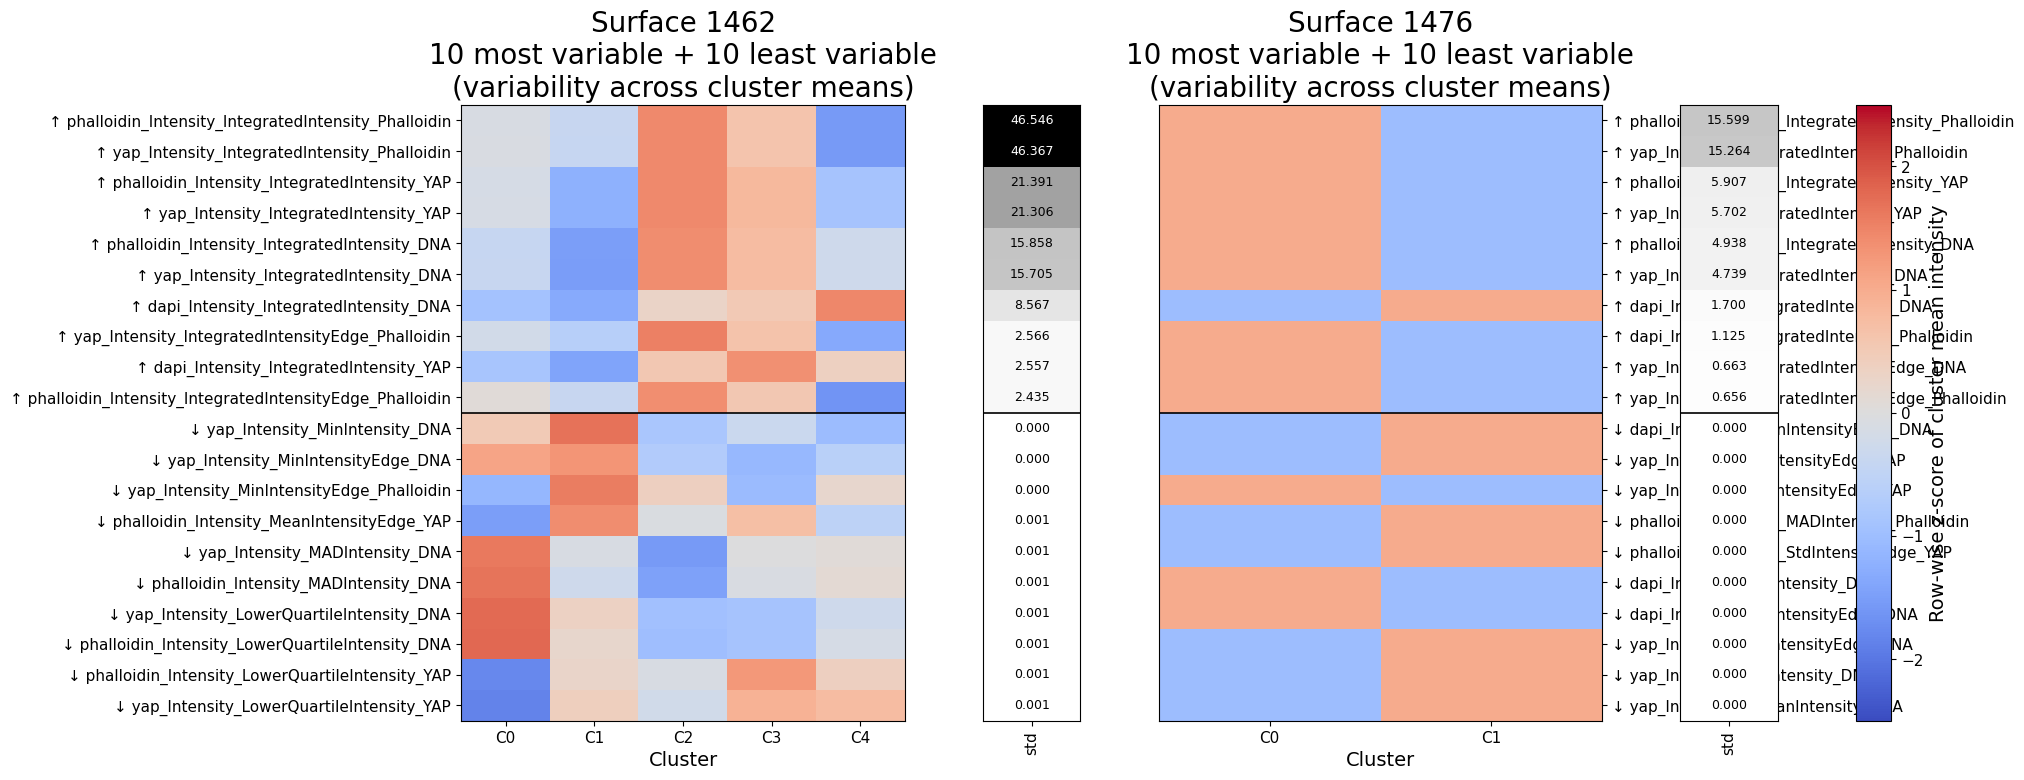

In [6]:

# Expecting exactly two surfaces, e.g. 1462 and 1476
surface_order = sorted(results.keys())
if len(surface_order) != 2:
    raise ValueError(f"Expected exactly 2 surfaces, found: {surface_order}")

fig, axes_dict = plot_combined_surface_intensity_variability(
    [results[surface_order[0]], results[surface_order[1]]],
    shorten_labels=False,
    show_std_values=True,
    variability_scale="global"
)


In [7]:
plot_export_table = pd.concat([
    pd.DataFrame({
        "surface": surface_name,
        "row_in_plot": range(1, len(summary["selected_feats"]) + 1),
        "metric_name": summary["selected_feats"],
        "group": [
            "most_variable" if f in summary["top_feats"] else "least_variable_nonzero"
            for f in summary["selected_feats"]
        ],
        "variability_std": [summary["variability_all"][f] for f in summary["selected_feats"]]
    })
    for surface_name, summary in results.items()
], ignore_index=True)

plot_export_path = DATA_DIR / "selected_intensity_variability_results.csv"
plot_export_table.to_csv(plot_export_path, index=False)
print(f"Saved plot-selection table: {plot_export_path}")


def build_top_bottom_variability_export(results_dict, top_n=150, bottom_n=150, exclude_overlap=True):
    """Export the most variable and least variable non-zero features per surface."""
    frames = []

    for surface_name, summary in results_dict.items():
        variability = summary["variability_all"].sort_values(ascending=False)

        top_series = variability.head(top_n)

        bottom_series = (
            variability.sort_values(ascending=True)
            .loc[lambda s: s > 0]
        )
        if exclude_overlap:
            bottom_series = bottom_series.loc[~bottom_series.index.isin(top_series.index)]
        bottom_series = bottom_series.head(bottom_n)

        top_df = pd.DataFrame({
            "surface": surface_name,
            "group": "most_variable",
            "rank_within_group": range(1, len(top_series) + 1),
            "metric_name": top_series.index,
            "variability_std": top_series.values,
            "zero_variability": np.isclose(top_series.values, 0.0),
        })

        bottom_df = pd.DataFrame({
            "surface": surface_name,
            "group": "least_variable_nonzero",
            "rank_within_group": range(1, len(bottom_series) + 1),
            "metric_name": bottom_series.index,
            "variability_std": bottom_series.values,
            "zero_variability": np.isclose(bottom_series.values, 0.0),
        })

        frames.extend([top_df, bottom_df])

    return pd.concat(frames, ignore_index=True)


variability_150_export = build_top_bottom_variability_export(results, top_n=150, bottom_n=150)
variability_150_export_path = DATA_DIR / "top_bottom_150_intensity_variability_results.csv"
variability_150_export.to_csv(variability_150_export_path, index=False)
print(f"Saved 150/150 variability table: {variability_150_export_path}")

display(plot_export_table.head())
display(variability_150_export.head())


Saved plot-selection table: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\selected_intensity_variability_results.csv
Saved 150/150 variability table: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\top_bottom_150_intensity_variability_results.csv


,surface,row_in_plot,metric_name,group,variability_std
0,1462,1,phalloidin_Intensity_IntegratedIntensity_Phall...,most_variable,46.546128
1,1462,2,yap_Intensity_IntegratedIntensity_Phalloidin,most_variable,46.366963
2,1462,3,phalloidin_Intensity_IntegratedIntensity_YAP,most_variable,21.390839
3,1462,4,yap_Intensity_IntegratedIntensity_YAP,most_variable,21.305870
4,1462,5,phalloidin_Intensity_IntegratedIntensity_DNA,most_variable,15.857790


,surface,group,rank_within_group,metric_name,variability_std,zero_variability
0,1462,most_variable,1,phalloidin_Intensity_IntegratedIntensity_Phall...,46.546128,False
1,1462,most_variable,2,yap_Intensity_IntegratedIntensity_Phalloidin,46.366963,False
2,1462,most_variable,3,phalloidin_Intensity_IntegratedIntensity_YAP,21.390839,False
3,1462,most_variable,4,yap_Intensity_IntegratedIntensity_YAP,21.305870,False
4,1462,most_variable,5,phalloidin_Intensity_IntegratedIntensity_DNA,15.857790,False


In [8]:
import re
from IPython.display import display


def explain_cp_metric(metric_name):
    """
    Convert a CellProfiler-style metric name into a short human-readable explanation.
    Expected style:
        <object>_Intensity_<measurement>_<channel>
    Example:
        dapi_Intensity_IntegratedIntensity_DNA
    """

    metric_name = str(metric_name)

    object_map = {
        "dapi": "segmented DAPI object",
        "phalloidin": "segmented phalloidin object",
        "yap": "segmented YAP object",
    }

    channel_map = {
        "DNA": "DNA channel",
        "Phalloidin": "phalloidin channel",
        "YAP": "YAP channel",
    }

    measurement_map = {
        "IntegratedIntensity": "sum of pixel intensities",
        "MeanIntensity": "mean pixel intensity",
        "StdIntensity": "standard deviation of pixel intensities",
        "MaxIntensity": "maximum pixel intensity",
        "MinIntensity": "minimum pixel intensity",
        "IntegratedIntensityEdge": "sum of edge-pixel intensities",
        "MeanIntensityEdge": "mean edge-pixel intensity",
        "StdIntensityEdge": "standard deviation of edge-pixel intensities",
        "MaxIntensityEdge": "maximum edge-pixel intensity",
        "MinIntensityEdge": "minimum edge-pixel intensity",
        "MassDisplacement": "distance between the binary-shape center and the intensity-weighted center",
        "LowerQuartileIntensity": "25th percentile of pixel intensities",
        "MedianIntensity": "median pixel intensity",
        "MADIntensity": "median absolute deviation of pixel intensities",
        "UpperQuartileIntensity": "75th percentile of pixel intensities",
        "Location_CenterMassIntensity_X": "X coordinate of the intensity-weighted center",
        "Location_CenterMassIntensity_Y": "Y coordinate of the intensity-weighted center",
        "Location_CenterMassIntensity_Z": "Z coordinate of the intensity-weighted center",
        "Location_MaxIntensity_X": "X coordinate of the brightest pixel",
        "Location_MaxIntensity_Y": "Y coordinate of the brightest pixel",
        "Location_MaxIntensity_Z": "Z coordinate of the brightest pixel",
    }

    percentile_match = re.search(r"(^|_)Percentile_(\d+)(_|$)", metric_name)
    percentile_text = None
    if percentile_match:
        p = percentile_match.group(2)
        percentile_text = f"{p}th percentile of pixel intensities"

    parts = metric_name.split("_")
    obj_prefix = parts[0] if len(parts) > 0 else None
    obj_text = object_map.get(obj_prefix, f"object '{obj_prefix}'" if obj_prefix else "object")

    channel_text = None
    for token in reversed(parts):
        if token in channel_map:
            channel_text = channel_map[token]
            break

    measurement_text = None
    for key, value in measurement_map.items():
        if key in metric_name:
            measurement_text = value
            break

    if measurement_text is None and percentile_text is not None:
        measurement_text = percentile_text

    if measurement_text is None:
        measurement_text = "intensity-derived measurement"

    if channel_text is not None:
        return f"{measurement_text} in the {channel_text}, measured within the {obj_text}"
    return f"{measurement_text} measured within the {obj_text}"


plot_export_table = pd.read_csv(plot_export_path)
plot_export_table["metric_explanation"] = plot_export_table["metric_name"].apply(explain_cp_metric)
plot_explained_path = DATA_DIR / "selected_intensity_variability_results_explained.csv"
plot_export_table.to_csv(plot_explained_path, index=False)
print(f"Saved explained plot-selection table: {plot_explained_path}")

variability_150_export = pd.read_csv(variability_150_export_path)
variability_150_export["metric_explanation"] = variability_150_export["metric_name"].apply(explain_cp_metric)
variability_150_explained_path = DATA_DIR / "top_bottom_150_intensity_variability_results_explained.csv"
variability_150_export.to_csv(variability_150_explained_path, index=False)
print(f"Saved explained 150/150 variability table: {variability_150_explained_path}")

display(plot_export_table.head(20))
display(variability_150_export.head(20))



Saved explained plot-selection table: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\selected_intensity_variability_results_explained.csv
Saved explained 150/150 variability table: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\top_bottom_150_intensity_variability_results_explained.csv


,surface,row_in_plot,metric_name,group,variability_std,metric_explanation
0,1462,1,phalloidin_Intensity_IntegratedIntensity_Phall...,most_variable,46.546128,sum of pixel intensities in the phalloidin cha...
1,1462,2,yap_Intensity_IntegratedIntensity_Phalloidin,most_variable,46.366963,sum of pixel intensities in the phalloidin cha...
2,1462,3,phalloidin_Intensity_IntegratedIntensity_YAP,most_variable,21.390839,"sum of pixel intensities in the YAP channel, m..."
3,1462,4,yap_Intensity_IntegratedIntensity_YAP,most_variable,21.305870,"sum of pixel intensities in the YAP channel, m..."
4,1462,5,phalloidin_Intensity_IntegratedIntensity_DNA,most_variable,15.857790,"sum of pixel intensities in the DNA channel, m..."
5,1462,6,yap_Intensity_IntegratedIntensity_DNA,most_variable,15.705078,"sum of pixel intensities in the DNA channel, m..."
6,1462,7,dapi_Intensity_IntegratedIntensity_DNA,most_variable,8.566974,"sum of pixel intensities in the DNA channel, m..."
7,1462,8,yap_Intensity_IntegratedIntensityEdge_Phalloidin,most_variable,2.566406,sum of pixel intensities in the phalloidin cha...
8,1462,9,dapi_Intensity_IntegratedIntensity_YAP,most_variable,2.556723,"sum of pixel intensities in the YAP channel, m..."
9,1462,10,phalloidin_Intensity_IntegratedIntensityEdge_P...,most_variable,2.434792,sum of pixel intensities in the phalloidin cha...


,surface,group,rank_within_group,metric_name,variability_std,zero_variability,metric_explanation
0,1462,most_variable,1,phalloidin_Intensity_IntegratedIntensity_Phall...,46.546128,False,sum of pixel intensities in the phalloidin cha...
1,1462,most_variable,2,yap_Intensity_IntegratedIntensity_Phalloidin,46.366963,False,sum of pixel intensities in the phalloidin cha...
2,1462,most_variable,3,phalloidin_Intensity_IntegratedIntensity_YAP,21.390839,False,"sum of pixel intensities in the YAP channel, m..."
3,1462,most_variable,4,yap_Intensity_IntegratedIntensity_YAP,21.305870,False,"sum of pixel intensities in the YAP channel, m..."
4,1462,most_variable,5,phalloidin_Intensity_IntegratedIntensity_DNA,15.857790,False,"sum of pixel intensities in the DNA channel, m..."
5,1462,most_variable,6,yap_Intensity_IntegratedIntensity_DNA,15.705078,False,"sum of pixel intensities in the DNA channel, m..."
6,1462,most_variable,7,dapi_Intensity_IntegratedIntensity_DNA,8.566974,False,"sum of pixel intensities in the DNA channel, m..."
7,1462,most_variable,8,yap_Intensity_IntegratedIntensityEdge_Phalloidin,2.566406,False,sum of pixel intensities in the phalloidin cha...
8,1462,most_variable,9,dapi_Intensity_IntegratedIntensity_YAP,2.556723,False,"sum of pixel intensities in the YAP channel, m..."
9,1462,most_variable,10,phalloidin_Intensity_IntegratedIntensityEdge_P...,2.434792,False,sum of pixel intensities in the phalloidin cha...


In [9]:
import numpy as np
import pandas as pd

def export_150_least_variable_nonzero(results_dict, out_csv="least_150_nonzero_variable_metrics.csv", n=150):
    frames = []

    for surface_name, summary in results_dict.items():
        variability = summary["variability_all"].copy()

        least_nonzero = (
            variability.sort_values(ascending=True)
            .loc[lambda s: s > 0]
            .head(n)
        )

        surface_df = pd.DataFrame({
            "surface": surface_name,
            "rank_within_surface": range(1, len(least_nonzero) + 1),
            "metric_name": least_nonzero.index,
            "variability_std": least_nonzero.values,
            "zero_variability": np.isclose(least_nonzero.values, 0.0),
        })

        frames.append(surface_df)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")
    return out_df

least_150_nonzero_df = export_150_least_variable_nonzero(results)
least_150_nonzero_df.head()

Saved: least_150_nonzero_variable_metrics.csv


,surface,rank_within_surface,metric_name,variability_std,zero_variability
0,1462,1,yap_Intensity_MinIntensity_DNA,0.000180,False
1,1462,2,yap_Intensity_MinIntensityEdge_DNA,0.000337,False
2,1462,3,yap_Intensity_MinIntensityEdge_Phalloidin,0.000354,False
3,1462,4,phalloidin_Intensity_MeanIntensityEdge_YAP,0.000509,False
4,1462,5,yap_Intensity_MADIntensity_DNA,0.000515,False


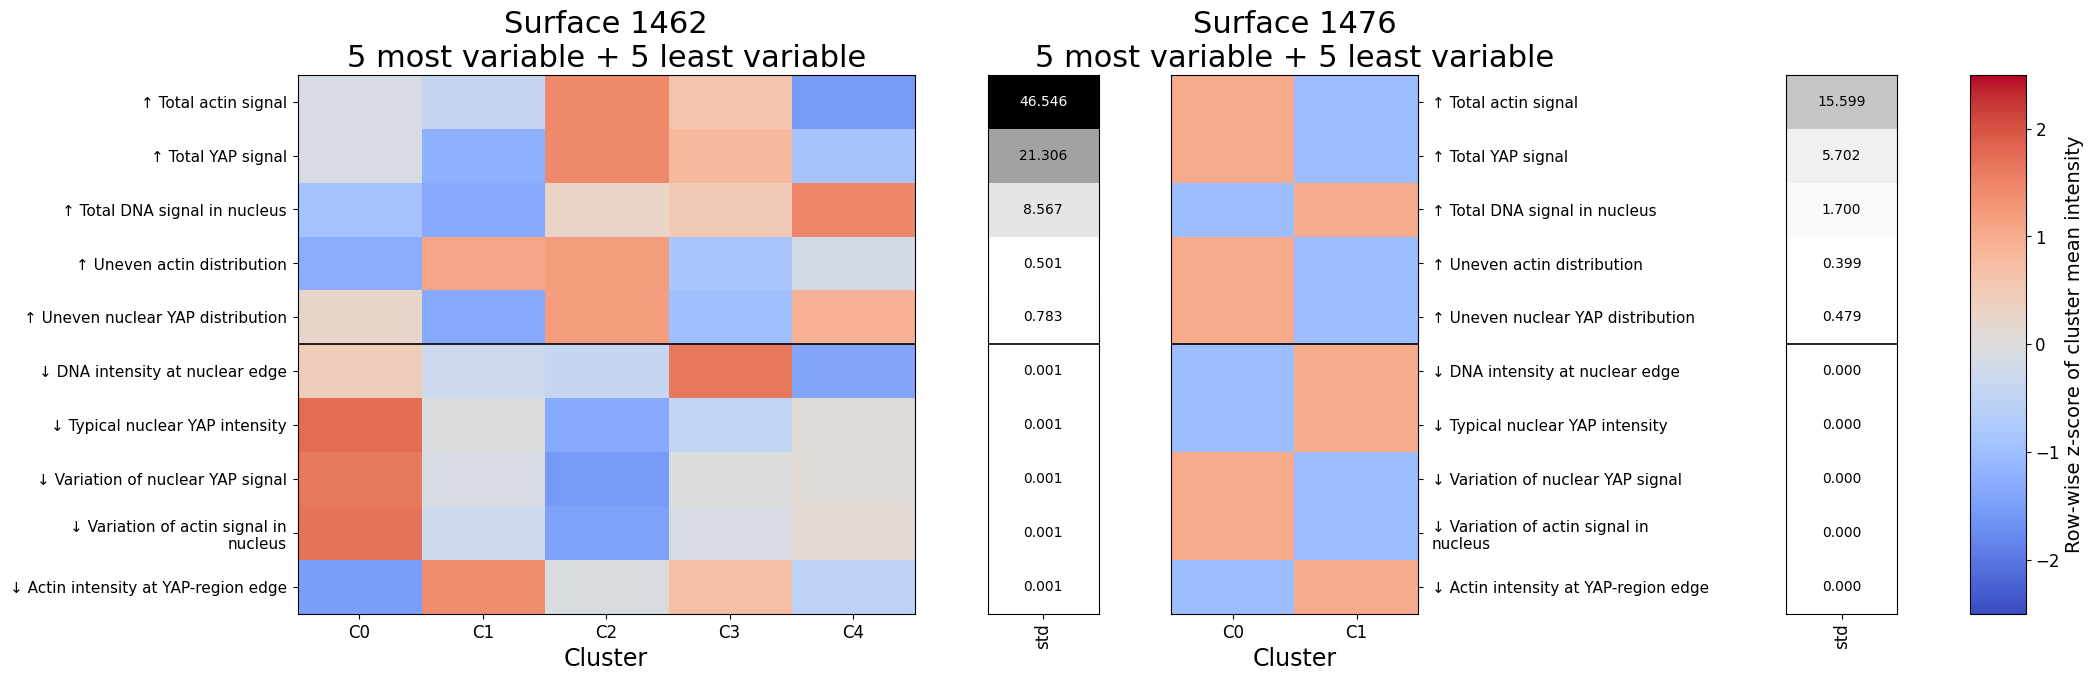

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import fill
import pandas as pd

# Short label shown on the heatmap
SIMPLE_METRIC_LABELS = {
    "phalloidin_Intensity_IntegratedIntensity_Phalloidin": "Total actin signal",
    "yap_Intensity_IntegratedIntensity_YAP": "Total YAP signal",
    "dapi_Intensity_IntegratedIntensity_DNA": "Total DNA signal in nucleus",
    "phalloidin_Intensity_MassDisplacement_Phalloidin": "Uneven actin distribution",
    "yap_Intensity_MassDisplacement_DNA": "Uneven nuclear YAP distribution",

    "dapi_Intensity_MeanIntensityEdge_DNA": "DNA intensity at nuclear edge",
    "yap_Intensity_MedianIntensity_DNA": "Typical nuclear YAP intensity",
    "yap_Intensity_MADIntensity_DNA": "Variation of nuclear YAP signal",
    "phalloidin_Intensity_MADIntensity_DNA": "Variation of actin signal in nucleus",
    "phalloidin_Intensity_MeanIntensityEdge_YAP": "Actin intensity at YAP-region edge",
}

# Longer explanation you can export as a legend/table
SIMPLE_METRIC_EXPLANATIONS = {
    "phalloidin_Intensity_IntegratedIntensity_Phalloidin": "Sum of all actin-channel intensity measured inside the actin-defined cell region.",
    "yap_Intensity_IntegratedIntensity_YAP": "Sum of all YAP-channel intensity measured inside the YAP-defined region.",
    "dapi_Intensity_IntegratedIntensity_DNA": "Sum of all DNA-channel intensity measured inside the nucleus.",
    "phalloidin_Intensity_MassDisplacement_Phalloidin": "How far the center of actin signal is shifted away from the center of the actin-defined region.",
    "yap_Intensity_MassDisplacement_DNA": "How far the center of YAP signal is shifted away from the center of the nucleus.",

    "dapi_Intensity_MeanIntensityEdge_DNA": "Average DNA intensity specifically at the nuclear border.",
    "yap_Intensity_MedianIntensity_DNA": "Middle YAP intensity value inside the nucleus; a robust typical nuclear YAP signal.",
    "yap_Intensity_MADIntensity_DNA": "How uneven the YAP signal is inside the nucleus.",
    "phalloidin_Intensity_MADIntensity_DNA": "How uneven the actin signal is within the nuclear area.",
    "phalloidin_Intensity_MeanIntensityEdge_YAP": "Average actin intensity at the edge of the YAP-defined region.",
}

def friendly_metric_label(metric_name, width=34):
    label = SIMPLE_METRIC_LABELS.get(metric_name, metric_name)
    return fill(label, width=width)

# Optional: export a legend table for the figure
selected_metrics = list(SIMPLE_METRIC_LABELS.keys())
figure_legend_df = pd.DataFrame({
    "metric_name": selected_metrics,
    "plot_label": [SIMPLE_METRIC_LABELS[m] for m in selected_metrics],
    "plain_explanation": [SIMPLE_METRIC_EXPLANATIONS[m] for m in selected_metrics],
})
figure_legend_df.to_csv(DATA_DIR / "selected_features_plain_language_legend.csv", index=False)
figure_legend_df

# ------------------------------------------------------------------
# 1) Define the features you want to show
# ------------------------------------------------------------------
top_features_to_display = [
    "phalloidin_Intensity_IntegratedIntensity_Phalloidin",
    "yap_Intensity_IntegratedIntensity_YAP",
    "dapi_Intensity_IntegratedIntensity_DNA",
    "phalloidin_Intensity_MassDisplacement_Phalloidin",
    "yap_Intensity_MassDisplacement_DNA",
]

bottom_features_to_display = [
    "dapi_Intensity_MeanIntensityEdge_DNA",
    "yap_Intensity_MedianIntensity_DNA",
    "yap_Intensity_MADIntensity_DNA",
    "phalloidin_Intensity_MADIntensity_DNA",
    "phalloidin_Intensity_MeanIntensityEdge_YAP",
]

# ------------------------------------------------------------------
# 2) Build a manual selection table for both surfaces
# ------------------------------------------------------------------
selection_rows = []
for surface_name in ["1462", "1476"]:
    row_counter = 1

    for feat in top_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "most_variable",
        })
        row_counter += 1

    for feat in bottom_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "least_variable_nonzero",
        })
        row_counter += 1

selection_df_manual = pd.DataFrame(selection_rows)

# ------------------------------------------------------------------
# 3) Rebuild surface summaries using only those selected features
# ------------------------------------------------------------------
results_selected = {
    surface_name: build_surface_summary(
        clustered_tables[surface_name],
        surface_name,
        selection_df=selection_df_manual
    )
    for surface_name in ["1462", "1476"]
}

# ------------------------------------------------------------------
# 4) Plot function with extra spacer so labels do not overlap std/cbar
# ------------------------------------------------------------------
def plot_selected_features_no_overlap(
    surface_summaries,
    cmap_heatmap="coolwarm",
    cmap_std="Greys",
    vmin=-2.5,
    vmax=2.5,
    figsize=(24, 7),
    shorten_labels=True,
    label_fontsize=11,
    tick_fontsize=12,
    title_fontsize=22,
    cbar_fontsize=14,
    std_fmt="{:.3f}",
    save_path=None,
):
    if len(surface_summaries) != 2:
        raise ValueError("Expected exactly 2 surface summaries.")

    # Global std scale across both surfaces
    all_std_vals = []
    for summary in surface_summaries:
        vals = summary["variability_all"].loc[summary["selected_feats"]].to_numpy(dtype=float)
        all_std_vals.extend(vals)

    std_vmin = float(np.nanmin(all_std_vals))
    std_vmax = float(np.nanmax(all_std_vals))
    if np.isclose(std_vmin, std_vmax):
        std_vmax = std_vmin + 1e-9

    fig = plt.figure(figsize=figsize)

    ncols_1 = surface_summaries[0]["heatmap_scaled"].shape[1]  # 1462 -> 5
    ncols_2 = surface_summaries[1]["heatmap_scaled"].shape[1]  # 1476 -> 2

    gs = fig.add_gridspec(
        1, 6,
        width_ratios=[ncols_1, 0.9, ncols_2, 1.8, 0.9, 0.45]
    )
    ax_hm_1 = fig.add_subplot(gs[0, 0])
    ax_std_1 = fig.add_subplot(gs[0, 1], sharey=ax_hm_1)

    ax_hm_2 = fig.add_subplot(gs[0, 2])
    ax_spacer = fig.add_subplot(gs[0, 3])   # empty spacer for right-side labels
    ax_std_2 = fig.add_subplot(gs[0, 4], sharey=ax_hm_2)

    cax = fig.add_subplot(gs[0, 5])

    ax_spacer.axis("off")

    heatmap_axes = [ax_hm_1, ax_hm_2]
    std_axes = [ax_std_1, ax_std_2]

    im_heat = None

    for idx, (ax_hm, ax_std, summary) in enumerate(zip(heatmap_axes, std_axes, surface_summaries)):
        heatmap_data = summary["heatmap_scaled"]
        row_labels = heatmap_data.index.tolist()
        col_labels = [f"C{c}" for c in heatmap_data.columns.tolist()]
        std_vals = summary["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

        im_heat = ax_hm.imshow(
            heatmap_data.values,
            aspect="auto",
            cmap=cmap_heatmap,
            vmin=vmin,
            vmax=vmax
        )

        ax_hm.set_xticks(np.arange(len(col_labels)))
        ax_hm.set_xticklabels(col_labels, fontsize=tick_fontsize)
        ax_hm.set_xlabel("Cluster", fontsize=17)

        display_row_labels = []
        for feat in row_labels:
            feat_disp = friendly_metric_label(feat, width=34) if shorten_labels else feat
            if feat in summary["top_feats"]:
                display_row_labels.append("↑ " + feat_disp)
            elif feat in summary["bottom_feats"]:
                display_row_labels.append("↓ " + feat_disp)
            else:
                display_row_labels.append(feat_disp)

        ax_hm.set_yticks(np.arange(len(display_row_labels)))
        ax_hm.set_yticklabels(display_row_labels, fontsize=label_fontsize)

        if idx == 0:
            ax_hm.yaxis.tick_left()
            ax_hm.tick_params(axis="y", labelleft=True, labelright=False, pad=4)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("right")
        else:
            # keep labels on the right, but they now expand into the empty spacer axis
            ax_hm.yaxis.tick_right()
            ax_hm.tick_params(axis="y", labelleft=False, labelright=True, pad=6)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("left")

        n_top = len(summary["top_feats"])
        ax_hm.axhline(n_top - 0.5, color="black", linewidth=1.2)

        ax_hm.set_title(
            f"Surface {summary['surface_name']}\n"
            f"{len(summary['top_feats'])} most variable + {len(summary['bottom_feats'])} least variable",
            fontsize=title_fontsize
        )

        # std side column
        ax_std.imshow(
            std_vals,
            aspect="auto",
            cmap=cmap_std,
            vmin=std_vmin,
            vmax=std_vmax
        )
        ax_std.set_xticks([0])
        ax_std.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
        ax_std.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        ax_std.axhline(n_top - 0.5, color="black", linewidth=1.2)

        std_norm = (std_vals.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
        for i, (val, norm_val) in enumerate(zip(std_vals.flatten(), std_norm)):
            text_color = "white" if norm_val > 0.6 else "black"
            ax_std.text(
                0, i,
                std_fmt.format(val),
                ha="center", va="center",
                fontsize=10,
                color=text_color
            )

    cbar = fig.colorbar(im_heat, cax=cax)
    cbar.set_label("Row-wise z-score of cluster mean intensity", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    fig.subplots_adjust(left=0.24, right=0.96, wspace=0.32)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


# ------------------------------------------------------------------
# 5) Plot and save
# ------------------------------------------------------------------
surface_order = ["1462", "1476"]
fig = plot_selected_features_no_overlap(
    [results_selected[s] for s in surface_order],
    shorten_labels=True,
    save_path=DATA_DIR / "selected_5_top_5_bottom_features_heatmap.png"
)

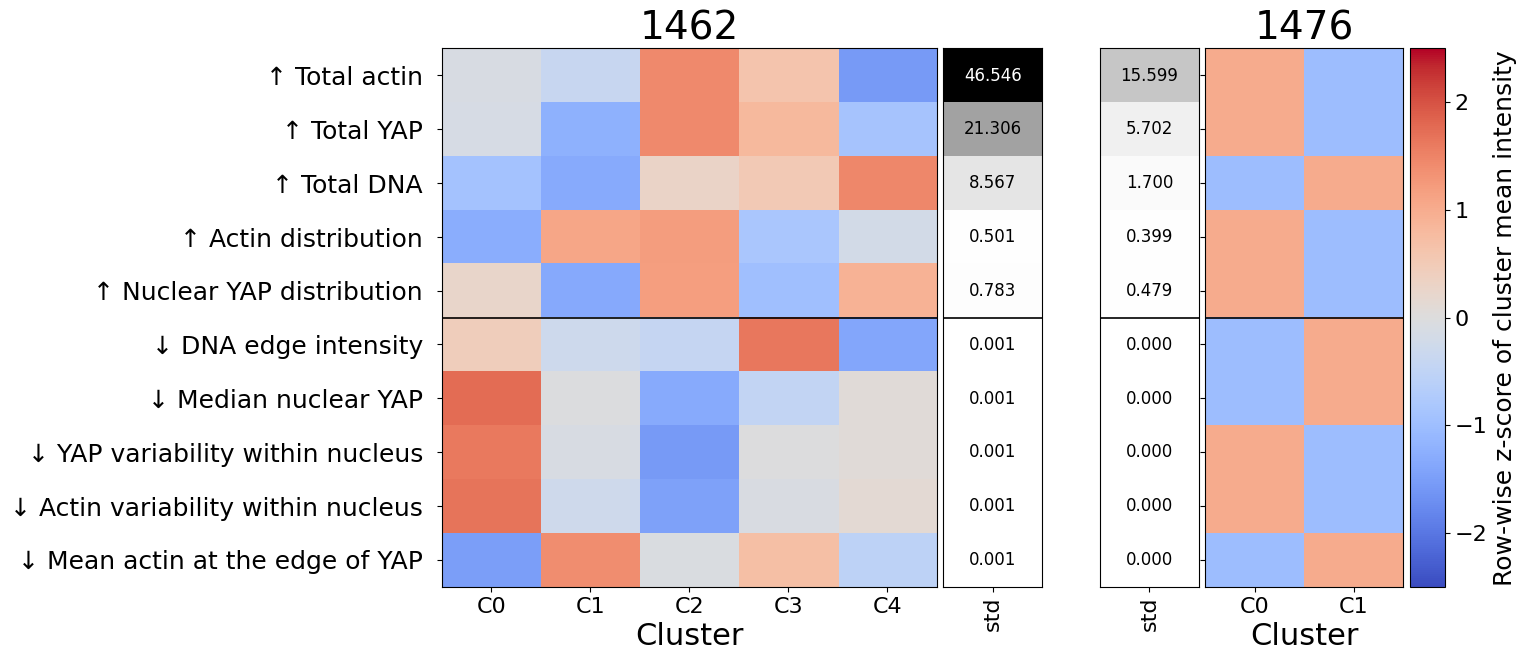

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# 0) Output folder
# ------------------------------------------------------------------
FIG9_DIR = Path(r"Z:\1 BIS\Shared folders\Jan\Artikel in opbouw\Nikita pseudotime analysis\3. main figure folder\Figure 9 morphological variability")

# ------------------------------------------------------------------
# 1) Short plain-language labels for the intensity figure
# ------------------------------------------------------------------
SIMPLE_METRIC_LABELS = {
    "phalloidin_Intensity_IntegratedIntensity_Phalloidin": "Total actin",
    "yap_Intensity_IntegratedIntensity_YAP": "Total YAP",
    "dapi_Intensity_IntegratedIntensity_DNA": "Total DNA",
    "phalloidin_Intensity_MassDisplacement_Phalloidin": "Actin distribution",
    "yap_Intensity_MassDisplacement_DNA": "Nuclear YAP distribution",

    "dapi_Intensity_MeanIntensityEdge_DNA": "DNA edge intensity",
    "yap_Intensity_MedianIntensity_DNA": "Median nuclear YAP",
    "yap_Intensity_MADIntensity_DNA": "YAP variability within nucleus",
    "phalloidin_Intensity_MADIntensity_DNA": "Actin variability within nucleus",
    "phalloidin_Intensity_MeanIntensityEdge_YAP": "Mean actin at the edge of YAP",
}

def friendly_metric_label(metric_name):
    return SIMPLE_METRIC_LABELS.get(metric_name, metric_name)

# ------------------------------------------------------------------
# 2) Header drawer: text only, no logo
# ------------------------------------------------------------------
def draw_surface_header(ax, surface_text):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.text(
        0.5, 0.52, surface_text,
        ha="center", va="center",
        fontsize=28,
        bbox=dict(facecolor="white", edgecolor="none", pad=3.5)
    )

# ------------------------------------------------------------------
# 3) Exact-layout plot for the intensity figure
# ------------------------------------------------------------------
def plot_intensity_figure_exact_layout(
    results_dict,
    save_path=None,
    figsize=(17, 7.2),
    facecolor="white",
    cmap_heatmap="coolwarm",
    cmap_std="Greys",
    vmin=-2.5,
    vmax=2.5,
    label_fontsize=18,
    tick_fontsize=16,
    std_number_fontsize=12,
    cbar_fontsize=18,
):
    summary_1462 = results_dict["1462"]
    summary_1476 = results_dict["1476"]

    hm_1462 = summary_1462["heatmap_scaled"]
    hm_1476 = summary_1476["heatmap_scaled"]

    # Make cell width equal between surfaces
    ncols_1462 = hm_1462.shape[1]
    ncols_1476 = hm_1476.shape[1]

    # Shared std scale
    std_vals_all = np.concatenate([
        summary_1462["variability_all"].loc[summary_1462["selected_feats"]].to_numpy(dtype=float),
        summary_1476["variability_all"].loc[summary_1476["selected_feats"]].to_numpy(dtype=float),
    ])
    std_vmin = float(np.nanmin(std_vals_all))
    std_vmax = float(np.nanmax(std_vals_all))
    if np.isclose(std_vmin, std_vmax):
        std_vmax = std_vmin + 1e-9

    fig = plt.figure(figsize=figsize, facecolor=facecolor)

    # Layout:
    # row 0: headers
    # row 1: left heatmap | left std | gap | right std | right heatmap | colorbar
    gs = fig.add_gridspec(
        2, 6,
        height_ratios=[0.42, 6.0],
        width_ratios=[ncols_1462, 1.0, 0.45, 1.0, ncols_1476, 0.35],
        hspace=0.00,
        wspace=0.04
    )

    ax_head_1462 = fig.add_subplot(gs[0, 0])
    ax_head_1476 = fig.add_subplot(gs[0, 4])

    ax_hm_1462  = fig.add_subplot(gs[1, 0])
    ax_std_1462 = fig.add_subplot(gs[1, 1], sharey=ax_hm_1462)

    ax_gap      = fig.add_subplot(gs[:, 2])
    ax_std_1476 = fig.add_subplot(gs[1, 3], sharey=ax_hm_1462)
    ax_hm_1476  = fig.add_subplot(gs[1, 4], sharey=ax_hm_1462)

    cax         = fig.add_subplot(gs[1, 5])

    ax_gap.axis("off")
    ax_gap.set_facecolor(facecolor)

    for ax in [ax_head_1462, ax_head_1476, ax_hm_1462, ax_std_1462, ax_std_1476, ax_hm_1476, cax]:
        ax.set_facecolor(facecolor)

    draw_surface_header(ax_head_1462, "1462")
    draw_surface_header(ax_head_1476, "1476")

    # ---------------------------
    # Left heatmap (1462)
    # ---------------------------
    im = ax_hm_1462.imshow(
        hm_1462.values,
        aspect="auto",
        cmap=cmap_heatmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    row_labels = hm_1462.index.tolist()
    display_row_labels = []
    for feat in row_labels:
        prefix = "↑ " if feat in summary_1462["top_feats"] else "↓ "
        display_row_labels.append(prefix + friendly_metric_label(feat))

    ax_hm_1462.set_yticks(np.arange(len(display_row_labels)))
    ax_hm_1462.set_yticklabels(display_row_labels, fontsize=label_fontsize)
    ax_hm_1462.tick_params(axis="y", labelleft=True, labelright=False, pad=10)

    ax_hm_1462.set_xticks(np.arange(hm_1462.shape[1]))
    ax_hm_1462.set_xticklabels([f"C{i}" for i in hm_1462.columns], fontsize=tick_fontsize)
    ax_hm_1462.set_xlabel("Cluster", fontsize=22)

    n_top = len(summary_1462["top_feats"])
    ax_hm_1462.axhline(n_top - 0.5, color="black", linewidth=1.2)

    # ---------------------------
    # Left std (1462)
    # ---------------------------
    std_1462 = summary_1462["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

    ax_std_1462.imshow(
        std_1462,
        aspect="auto",
        cmap=cmap_std,
        vmin=std_vmin,
        vmax=std_vmax,
        interpolation="nearest"
    )
    ax_std_1462.set_xticks([0])
    ax_std_1462.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
    ax_std_1462.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax_std_1462.axhline(n_top - 0.5, color="black", linewidth=1.2)

    norm_1462 = (std_1462.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
    for i, (val, norm_val) in enumerate(zip(std_1462.flatten(), norm_1462)):
        ax_std_1462.text(
            0, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=std_number_fontsize,
            color="white" if norm_val > 0.6 else "black"
        )

    # ---------------------------
    # Right std (1476)
    # ---------------------------
    std_1476 = summary_1476["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

    ax_std_1476.imshow(
        std_1476,
        aspect="auto",
        cmap=cmap_std,
        vmin=std_vmin,
        vmax=std_vmax,
        interpolation="nearest"
    )
    ax_std_1476.set_xticks([0])
    ax_std_1476.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
    ax_std_1476.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax_std_1476.axhline(n_top - 0.5, color="black", linewidth=1.2)

    norm_1476 = (std_1476.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
    for i, (val, norm_val) in enumerate(zip(std_1476.flatten(), norm_1476)):
        ax_std_1476.text(
            0, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=std_number_fontsize,
            color="white" if norm_val > 0.6 else "black"
        )

    # ---------------------------
    # Right heatmap (1476)
    # ---------------------------
    ax_hm_1476.imshow(
        hm_1476.values,
        aspect="auto",
        cmap=cmap_heatmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax_hm_1476.set_xticks(np.arange(hm_1476.shape[1]))
    ax_hm_1476.set_xticklabels([f"C{i}" for i in hm_1476.columns], fontsize=tick_fontsize)
    ax_hm_1476.set_xlabel("Cluster", fontsize=22)

    # Hide duplicate row labels on the right panel
    ax_hm_1476.set_yticks(np.arange(len(row_labels)))
    ax_hm_1476.tick_params(axis="y", labelleft=False, labelright=False)
    ax_hm_1476.axhline(n_top - 0.5, color="black", linewidth=1.2)

    # ---------------------------
    # Colorbar
    # ---------------------------
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Row-wise z-score of cluster mean intensity", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Final spacing
    fig.subplots_adjust(
        left=0.38,
        right=0.97,
        top=0.94,
        bottom=0.14,
        wspace=0.04
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

    plt.show()
    return fig

# ------------------------------------------------------------------
# 4) Make the figure
# ------------------------------------------------------------------
fig = plot_intensity_figure_exact_layout(
    results_selected,
    save_path=FIG9_DIR / "figure 9 intensity.png"
)

In [28]:
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Feature selection: everything numeric EXCEPT intensity
# ------------------------------------------------------------
def get_nonint_feature_columns(df, cluster_col):
    df = clean_column_names(df)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != cluster_col]

    # Drop obvious IDs / bookkeeping columns, but keep real CP features
    drop_exact = {
        "ImageNumber", "ObjectNumber", "ObjectCenterX", "ObjectCenterY",
        "Metadata_Plate", "Metadata_Well"
    }
    drop_prefixes = (
        "Metadata_", "FileName_", "PathName_", "URL_", "Group_", "ExecutionTime_",
        "Parent_", "Children_", "Count_", "Number_",
    )

    keep = []
    for c in numeric_cols:
        s = str(c).strip()

        if "_Intensity_" in s:
            continue
        if s in drop_exact:
            continue
        if any(s.startswith(p) for p in drop_prefixes):
            continue
        if s.lower().startswith("cluster"):
            continue
        if s.lower().startswith("unnamed"):
            continue

        keep.append(s)

    return keep


def build_surface_summary_nonint(df, surface_name, selection_df=None, top_n=150, bottom_n=150):
    df = clean_column_names(df)
    cluster_col = get_cluster_column_for_surface(df, surface_name)
    feature_cols = get_nonint_feature_columns(df, cluster_col)

    if not feature_cols:
        raise ValueError(f"No usable non-intensity feature columns found for surface {surface_name}.")

    cluster_means = df.groupby(cluster_col)[feature_cols].mean().sort_index()
    variability_all = cluster_means.std(axis=0, ddof=0).sort_values(ascending=False)

    if selection_df is not None and not selection_df.empty:
        sel = selection_df[selection_df["surface"].astype(str) == str(surface_name)].copy()

        if "row_in_plot" in sel.columns:
            sel = sel.sort_values("row_in_plot")

        selected_feats = [f for f in sel["metric_name"].tolist() if f in cluster_means.columns]
        top_feats = [f for f in sel.loc[sel["group"] == "most_variable", "metric_name"].tolist() if f in selected_feats]
        bottom_feats = [f for f in sel.loc[sel["group"] != "most_variable", "metric_name"].tolist() if f in selected_feats]

        if not selected_feats:
            raise ValueError(f"No selected metrics matched columns for surface {surface_name}.")
    else:
        top_feats = variability_all.head(top_n).index.tolist()
        bottom_feats = (
            variability_all.sort_values(ascending=True)
            .loc[lambda s: s > 0]
            .loc[lambda s: ~s.index.isin(top_feats)]
            .head(bottom_n)
            .index.tolist()
        )
        selected_feats = top_feats + bottom_feats

    heatmap_raw = cluster_means[selected_feats].T
    heatmap_scaled = rowwise_zscore(heatmap_raw)

    return {
        "surface_name": str(surface_name),
        "cluster_col": cluster_col,
        "cluster_means": cluster_means,
        "variability_all": variability_all,
        "selected_feats": selected_feats,
        "top_feats": top_feats,
        "bottom_feats": bottom_feats,
        "heatmap_scaled": heatmap_scaled,
    }


# ------------------------------------------------------------
# 2) Build results for non-intensity features
# ------------------------------------------------------------
results_nonint = {
    surface_name: build_surface_summary_nonint(df, surface_name)
    for surface_name, df in clustered_tables.items()
}

for surface_name, summary in results_nonint.items():
    print(
        f"Surface {surface_name}: "
        f"{len(summary['variability_all'])} non-intensity features "
        f"(top={len(summary['top_feats'])}, bottom={len(summary['bottom_feats'])})"
    )


# ------------------------------------------------------------
# 3) Export top/bottom 150 non-intensity features
# ------------------------------------------------------------
def build_top_bottom_variability_export(results_dict, top_n=150, bottom_n=150):
    frames = []

    for surface_name, summary in results_dict.items():
        variability = summary["variability_all"].copy()

        top_series = variability.sort_values(ascending=False).head(top_n)
        bottom_series = (
            variability.sort_values(ascending=True)
            .loc[lambda s: s > 0]
            .loc[lambda s: ~s.index.isin(top_series.index)]
            .head(bottom_n)
        )

        top_df = pd.DataFrame({
            "surface": surface_name,
            "group": "most_variable",
            "rank_within_group": range(1, len(top_series) + 1),
            "metric_name": top_series.index,
            "variability_std": top_series.values,
        })

        bottom_df = pd.DataFrame({
            "surface": surface_name,
            "group": "least_variable_nonzero",
            "rank_within_group": range(1, len(bottom_series) + 1),
            "metric_name": bottom_series.index,
            "variability_std": bottom_series.values,
        })

        frames.extend([top_df, bottom_df])

    return pd.concat(frames, ignore_index=True)


top_bottom_150_nonint = build_top_bottom_variability_export(results_nonint, top_n=150, bottom_n=150)
top_bottom_150_nonint.to_csv(DATA_DIR / "top_bottom_150_nonint_variability_results.csv", index=False)

least_150_nonzero_nonint = pd.concat([
    pd.DataFrame({
        "surface": surface_name,
        "rank_within_surface": range(
            1,
            len(
                summary["variability_all"].sort_values(ascending=True).loc[lambda s: s > 0].head(150)
            ) + 1
        ),
        "metric_name": summary["variability_all"].sort_values(ascending=True).loc[lambda s: s > 0].head(150).index,
        "variability_std": summary["variability_all"].sort_values(ascending=True).loc[lambda s: s > 0].head(150).values,
    })
    for surface_name, summary in results_nonint.items()
], ignore_index=True)
least_150_nonzero_nonint.to_csv(DATA_DIR / "least_150_nonzero_nonint_variable_metrics.csv", index=False)

print("Saved:")
print(DATA_DIR / "top_bottom_150_nonint_variability_results.csv")
print(DATA_DIR / "least_150_nonzero_nonint_variable_metrics.csv")

Surface 1462: 1807 non-intensity features (top=150, bottom=150)
Surface 1476: 1807 non-intensity features (top=150, bottom=150)
Saved:
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\top_bottom_150_nonint_variability_results.csv
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\least_150_nonzero_nonint_variable_metrics.csv


In [19]:
def cp_family(metric_name):
    s = str(metric_name)
    parts = s.split("_")
    return parts[1] if len(parts) > 1 else "Unknown"

def preview_nonint_candidates(results_dict, n=25):
    for surface_name, summary in results_dict.items():
        variability = summary["variability_all"]

        top_df = (
            variability.sort_values(ascending=False)
            .head(n)
            .rename("variability_std")
            .reset_index()
            .rename(columns={"index": "metric_name"})
        )
        top_df["family"] = top_df["metric_name"].map(cp_family)
        top_df["group"] = "top"

        bottom_df = (
            variability.sort_values(ascending=True)
            .loc[lambda s: s > 0]
            .head(n)
            .rename("variability_std")
            .reset_index()
            .rename(columns={"index": "metric_name"})
        )
        bottom_df["family"] = bottom_df["metric_name"].map(cp_family)
        bottom_df["group"] = "bottom"

        preview = pd.concat([top_df, bottom_df], ignore_index=True)
        print(f"\n===== Surface {surface_name} =====")
        display(preview)

preview_nonint_candidates(results_nonint, n=25)


===== Surface 1462 =====


,metric_name,variability_std,family,group
0,sizeshape.SpatialMoment_2_3,1.182869e+08,2,top
1,sizeshape.SpatialMoment_1_3,5.246580e+06,1,top
2,sizeshape.SpatialMoment_2_2,3.065205e+06,2,top
3,sizeshape.CentralMoment_2_3,5.876775e+05,2,top
4,sizeshape.CentralMoment_1_3,2.720950e+05,1,top
5,sizeshape.SpatialMoment_0_3,2.343427e+05,0,top
6,sizeshape.CentralMoment_2_2,1.396196e+05,2,top
7,sizeshape.SpatialMoment_1_2,1.344442e+05,1,top
8,sizeshape.SpatialMoment_2_1,8.897844e+04,2,top
9,sizeshape.CentralMoment_0_3,6.089163e+03,0,top



===== Surface 1476 =====


,metric_name,variability_std,family,group
0,sizeshape.SpatialMoment_2_3,1.391232e+07,2,top
1,sizeshape.SpatialMoment_1_3,1.504342e+06,1,top
2,sizeshape.CentralMoment_2_3,5.798648e+05,2,top
3,sizeshape.SpatialMoment_2_2,4.159692e+05,2,top
4,sizeshape.SpatialMoment_0_3,1.838572e+05,0,top
5,sizeshape.CentralMoment_1_3,6.986813e+04,1,top
6,sizeshape.SpatialMoment_1_2,5.178515e+04,1,top
7,sizeshape.CentralMoment_2_2,1.829495e+04,2,top
8,sizeshape.CentralMoment_1_2,6.916197e+03,1,top
9,sizeshape.SpatialMoment_0_2,6.912670e+03,0,top


In [20]:
top_nonint_features_to_display = [
    "phalloidin_AreaShape_BoundingBoxArea",
    "dapi_Texture_SumVariance_DNA_3_01_256",
    "dapi_Texture_Contrast_DNA_3_03_256",
    "sizeshape.Orientation",
    "granularity.Granularity_6",
]

bottom_nonint_features_to_display = [
    "dapi_Texture_DifferenceVariance_DNA_3_01_256",
    "phalloidin_Texture_DifferenceVariance_Phalloidin_3_00_256",
    "phalloidin_Texture_AngularSecondMoment_Phalloidin_3_01_256",
    "yap_Texture_DifferenceVariance_DNA_3_01_256",
    "yap_Texture_AngularSecondMoment_Phalloidin_3_01_256",
]

In [21]:
from textwrap import fill
import pandas as pd

# ------------------------------------------------------------
# 4) Fill these in after reviewing the exported non-intensity tables
# ------------------------------------------------------------
top_nonint_features_to_display = [
    # "dapi_AreaShape_Area",
    # "dapi_AreaShape_Eccentricity",
    # "phalloidin_Texture_Contrast_Phalloidin_3_00",
    # ...
]

bottom_nonint_features_to_display = [
    # "dapi_AreaShape_FormFactor",
    # "yap_Texture_Entropy_YAP_3_00",
    # ...
]

# Plain-language labels for the 10 selected features
SIMPLE_NONINT_LABELS = {
    # "dapi_AreaShape_Area": "Nuclear area",
    # "dapi_AreaShape_Eccentricity": "How elongated the nucleus is",
    # "phalloidin_Texture_Contrast_Phalloidin_3_00": "How patchy the actin pattern is",
}

SIMPLE_NONINT_EXPLANATIONS = {
    # "dapi_AreaShape_Area": "Total size of the segmented nucleus.",
    # "dapi_AreaShape_Eccentricity": "Whether the nucleus is round or stretched out.",
    # "phalloidin_Texture_Contrast_Phalloidin_3_00": "How strongly neighboring actin pixels differ in intensity.",
}

def friendly_nonint_label(metric_name, width=30):
    return fill(SIMPLE_NONINT_LABELS.get(metric_name, metric_name), width=width)


# ------------------------------------------------------------
# 5) Manual selection table for plotting
# ------------------------------------------------------------
selection_rows = []
for surface_name in ["1462", "1476"]:
    row_counter = 1

    for feat in top_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "most_variable",
        })
        row_counter += 1

    for feat in bottom_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "least_variable_nonzero",
        })
        row_counter += 1

selection_df_nonint_manual = pd.DataFrame(selection_rows)

results_nonint_selected = {
    surface_name: build_surface_summary_nonint(
        clustered_tables[surface_name],
        surface_name,
        selection_df=selection_df_nonint_manual
    )
    for surface_name in ["1462", "1476"]
}

legend_df_nonint = pd.DataFrame({
    "metric_name": list(SIMPLE_NONINT_LABELS.keys()),
    "plot_label": [SIMPLE_NONINT_LABELS[k] for k in SIMPLE_NONINT_LABELS],
    "plain_explanation": [SIMPLE_NONINT_EXPLANATIONS.get(k, "") for k in SIMPLE_NONINT_LABELS],
})
legend_df_nonint.to_csv(DATA_DIR / "selected_nonint_features_plain_language_legend.csv", index=False)
legend_df_nonint

,metric_name,plot_label,plain_explanation


In [23]:
selection_rows = []
for surface_name in ["1462", "1476"]:
    row_counter = 1

    for feat in top_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "most_variable",
        })
        row_counter += 1

    for feat in bottom_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "least_variable_nonzero",
        })
        row_counter += 1

selection_df_nonint_manual = pd.DataFrame(selection_rows)

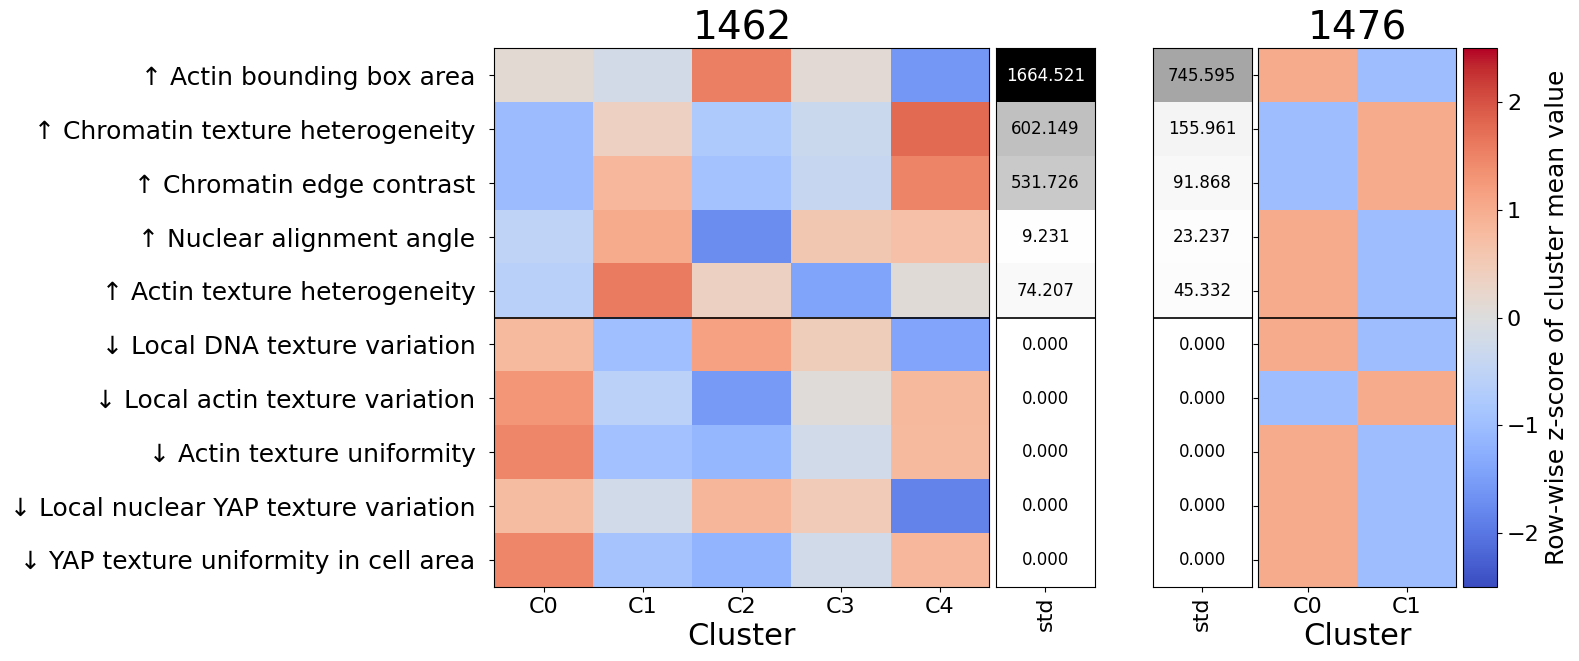

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# 0) Output folder
# ------------------------------------------------------------------
FIG9_DIR = Path(r"Z:\1 BIS\Shared folders\Jan\Artikel in opbouw\Nikita pseudotime analysis\3. main figure folder\Figure 9 morphological variability")

# ------------------------------------------------------------------
# 1) Selected non-intensity features to display
# ------------------------------------------------------------------
top_nonint_features_to_display = [
    "phalloidin_AreaShape_BoundingBoxArea",
    "dapi_Texture_SumVariance_DNA_3_01_256",
    "dapi_Texture_Contrast_DNA_3_03_256",
    "sizeshape.Orientation",
    "phalloidin_Texture_SumVariance_Phalloidin_3_01_256",
]

bottom_nonint_features_to_display = [
    "dapi_Texture_DifferenceVariance_DNA_3_01_256",
    "phalloidin_Texture_DifferenceVariance_Phalloidin_3_00_256",
    "phalloidin_Texture_AngularSecondMoment_Phalloidin_3_01_256",
    "yap_Texture_DifferenceVariance_DNA_3_01_256",
    "yap_Texture_AngularSecondMoment_Phalloidin_3_01_256",
]

# ------------------------------------------------------------------
# 2) Plain-language labels
# ------------------------------------------------------------------
SIMPLE_NONINT_LABELS = {
    "phalloidin_AreaShape_BoundingBoxArea": "Actin bounding box area",
    "dapi_Texture_SumVariance_DNA_3_01_256": "Chromatin texture heterogeneity",
    "dapi_Texture_Contrast_DNA_3_03_256": "Chromatin edge contrast",
    "sizeshape.Orientation": "Nuclear alignment angle",
    "phalloidin_Texture_SumVariance_Phalloidin_3_01_256": "Actin texture heterogeneity",

    "dapi_Texture_DifferenceVariance_DNA_3_01_256": "Local DNA texture variation",
    "phalloidin_Texture_DifferenceVariance_Phalloidin_3_00_256": "Local actin texture variation",
    "phalloidin_Texture_AngularSecondMoment_Phalloidin_3_01_256": "Actin texture uniformity",
    "yap_Texture_DifferenceVariance_DNA_3_01_256": "Local nuclear YAP texture variation",
    "yap_Texture_AngularSecondMoment_Phalloidin_3_01_256": "YAP texture uniformity in cell area",
}

SIMPLE_NONINT_EXPLANATIONS = {
    "phalloidin_AreaShape_BoundingBoxArea": "How much 2D space the actin-defined cell occupies from side to side.",
    "dapi_Texture_SumVariance_DNA_3_01_256": "How uneven and heterogeneous the DNA pattern is inside the nucleus.",
    "dapi_Texture_Contrast_DNA_3_03_256": "How strongly bright and dim DNA regions differ from each other.",
    "sizeshape.Orientation": "The angle of the nucleus relative to the image axes.",
    "phalloidin_Texture_SumVariance_Phalloidin_3_01_256": "Measures how uneven or patchy the actin staining pattern is within the cell region, using texture analysis of pixels 3 pixels apart.",

    "dapi_Texture_DifferenceVariance_DNA_3_01_256": "How much local DNA intensity changes vary from place to place inside the nucleus.",
    "phalloidin_Texture_DifferenceVariance_Phalloidin_3_00_256": "How much local actin intensity changes vary across the cell area.",
    "phalloidin_Texture_AngularSecondMoment_Phalloidin_3_01_256": "How uniform or patchy the actin pattern is.",
    "yap_Texture_DifferenceVariance_DNA_3_01_256": "How much local nuclear YAP intensity changes vary inside the nucleus.",
    "yap_Texture_AngularSecondMoment_Phalloidin_3_01_256": "How uniform or patchy the YAP pattern is across the cell area.",
}

def friendly_nonint_label(metric_name):
    return SIMPLE_NONINT_LABELS.get(metric_name, metric_name)

# ------------------------------------------------------------------
# 3) Manual selection table: only 5 top + 5 bottom
# ------------------------------------------------------------------
selection_rows = []
for surface_name in ["1462", "1476"]:
    row_counter = 1

    for feat in top_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "most_variable",
        })
        row_counter += 1

    for feat in bottom_nonint_features_to_display:
        selection_rows.append({
            "surface": surface_name,
            "row_in_plot": row_counter,
            "metric_name": feat,
            "group": "least_variable_nonzero",
        })
        row_counter += 1

selection_df_nonint_manual = pd.DataFrame(selection_rows)

# ------------------------------------------------------------------
# 4) Build summaries using only those 10 selected features
# ------------------------------------------------------------------
results_nonint_selected = {
    surface_name: build_surface_summary_nonint(
        clustered_tables[surface_name],
        surface_name,
        selection_df=selection_df_nonint_manual
    )
    for surface_name in ["1462", "1476"]
}

# Optional legend export
legend_df_nonint = pd.DataFrame({
    "metric_name": list(SIMPLE_NONINT_LABELS.keys()),
    "plot_label": [SIMPLE_NONINT_LABELS[k] for k in SIMPLE_NONINT_LABELS],
    "plain_explanation": [SIMPLE_NONINT_EXPLANATIONS.get(k, "") for k in SIMPLE_NONINT_LABELS],
})
legend_df_nonint.to_csv(FIG9_DIR / "selected_5_top_5_bottom_nonint_features_legend.csv", index=False)

# ------------------------------------------------------------------
# 5) Header drawer: text only, no logo
# ------------------------------------------------------------------
def draw_surface_header(ax, surface_text):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.text(
        0.5, 0.52, surface_text,
        ha="center", va="center",
        fontsize=28,
        bbox=dict(facecolor="white", edgecolor="none", pad=3.5)
    )

# ------------------------------------------------------------------
# 6) Exact-layout plot for the non-intensity figure
# ------------------------------------------------------------------
def plot_nonint_figure_exact_layout(
    results_dict,
    save_path=None,
    figsize=(17, 7.2),
    facecolor="white",
    cmap_heatmap="coolwarm",
    cmap_std="Greys",
    vmin=-2.5,
    vmax=2.5,
    label_fontsize=18,
    tick_fontsize=16,
    std_number_fontsize=12,
    cbar_fontsize=18,
):
    summary_1462 = results_dict["1462"]
    summary_1476 = results_dict["1476"]

    hm_1462 = summary_1462["heatmap_scaled"]
    hm_1476 = summary_1476["heatmap_scaled"]

    # Make cell width equal between surfaces
    ncols_1462 = hm_1462.shape[1]
    ncols_1476 = hm_1476.shape[1]

    # Shared std scale
    std_vals_all = np.concatenate([
        summary_1462["variability_all"].loc[summary_1462["selected_feats"]].to_numpy(dtype=float),
        summary_1476["variability_all"].loc[summary_1476["selected_feats"]].to_numpy(dtype=float),
    ])
    std_vmin = float(np.nanmin(std_vals_all))
    std_vmax = float(np.nanmax(std_vals_all))
    if np.isclose(std_vmin, std_vmax):
        std_vmax = std_vmin + 1e-9

    fig = plt.figure(figsize=figsize, facecolor=facecolor)

    # Layout:
    # row 0: headers
    # row 1: left heatmap | left std | gap | right std | right heatmap | colorbar
    gs = fig.add_gridspec(
        2, 6,
        height_ratios=[0.42, 6.0],
        width_ratios=[ncols_1462, 1.0, 0.45, 1.0, ncols_1476, 0.35],
        hspace=0.00,
        wspace=0.04
    )

    ax_head_1462 = fig.add_subplot(gs[0, 0])
    ax_head_1476 = fig.add_subplot(gs[0, 4])

    ax_hm_1462  = fig.add_subplot(gs[1, 0])
    ax_std_1462 = fig.add_subplot(gs[1, 1], sharey=ax_hm_1462)

    ax_gap      = fig.add_subplot(gs[:, 2])
    ax_std_1476 = fig.add_subplot(gs[1, 3], sharey=ax_hm_1462)
    ax_hm_1476  = fig.add_subplot(gs[1, 4], sharey=ax_hm_1462)

    cax         = fig.add_subplot(gs[1, 5])

    ax_gap.axis("off")
    ax_gap.set_facecolor(facecolor)

    for ax in [ax_head_1462, ax_head_1476, ax_hm_1462, ax_std_1462, ax_std_1476, ax_hm_1476, cax]:
        ax.set_facecolor(facecolor)

    draw_surface_header(ax_head_1462, "1462")
    draw_surface_header(ax_head_1476, "1476")

    # ---------------------------
    # Left heatmap (1462)
    # ---------------------------
    im = ax_hm_1462.imshow(
        hm_1462.values,
        aspect="auto",
        cmap=cmap_heatmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    row_labels = hm_1462.index.tolist()
    display_row_labels = []
    for feat in row_labels:
        prefix = "↑ " if feat in summary_1462["top_feats"] else "↓ "
        display_row_labels.append(prefix + friendly_nonint_label(feat))

    ax_hm_1462.set_yticks(np.arange(len(display_row_labels)))
    ax_hm_1462.set_yticklabels(display_row_labels, fontsize=label_fontsize)
    ax_hm_1462.tick_params(axis="y", labelleft=True, labelright=False, pad=10)

    ax_hm_1462.set_xticks(np.arange(hm_1462.shape[1]))
    ax_hm_1462.set_xticklabels([f"C{i}" for i in hm_1462.columns], fontsize=tick_fontsize)
    ax_hm_1462.set_xlabel("Cluster", fontsize=22)

    n_top = len(summary_1462["top_feats"])
    ax_hm_1462.axhline(n_top - 0.5, color="black", linewidth=1.2)

    # ---------------------------
    # Left std (1462)
    # ---------------------------
    std_1462 = summary_1462["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

    ax_std_1462.imshow(
        std_1462,
        aspect="auto",
        cmap=cmap_std,
        vmin=std_vmin,
        vmax=std_vmax,
        interpolation="nearest"
    )
    ax_std_1462.set_xticks([0])
    ax_std_1462.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
    ax_std_1462.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax_std_1462.axhline(n_top - 0.5, color="black", linewidth=1.2)

    norm_1462 = (std_1462.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
    for i, (val, norm_val) in enumerate(zip(std_1462.flatten(), norm_1462)):
        ax_std_1462.text(
            0, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=std_number_fontsize,
            color="white" if norm_val > 0.6 else "black"
        )

    # ---------------------------
    # Right std (1476)
    # ---------------------------
    std_1476 = summary_1476["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

    ax_std_1476.imshow(
        std_1476,
        aspect="auto",
        cmap=cmap_std,
        vmin=std_vmin,
        vmax=std_vmax,
        interpolation="nearest"
    )
    ax_std_1476.set_xticks([0])
    ax_std_1476.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
    ax_std_1476.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
    ax_std_1476.axhline(n_top - 0.5, color="black", linewidth=1.2)

    norm_1476 = (std_1476.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
    for i, (val, norm_val) in enumerate(zip(std_1476.flatten(), norm_1476)):
        ax_std_1476.text(
            0, i, f"{val:.3f}",
            ha="center", va="center",
            fontsize=std_number_fontsize,
            color="white" if norm_val > 0.6 else "black"
        )

    # ---------------------------
    # Right heatmap (1476)
    # ---------------------------
    ax_hm_1476.imshow(
        hm_1476.values,
        aspect="auto",
        cmap=cmap_heatmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax_hm_1476.set_xticks(np.arange(hm_1476.shape[1]))
    ax_hm_1476.set_xticklabels([f"C{i}" for i in hm_1476.columns], fontsize=tick_fontsize)
    ax_hm_1476.set_xlabel("Cluster", fontsize=22)

    # Hide duplicate row labels on the right panel
    ax_hm_1476.set_yticks(np.arange(len(row_labels)))
    ax_hm_1476.tick_params(axis="y", labelleft=False, labelright=False)
    ax_hm_1476.axhline(n_top - 0.5, color="black", linewidth=1.2)

    # ---------------------------
    # Colorbar
    # ---------------------------
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Row-wise z-score of cluster mean value", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Final spacing
    fig.subplots_adjust(
        left=0.38,
        right=0.97,
        top=0.94,
        bottom=0.14,
        wspace=0.04
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

    plt.show()
    return fig

# ------------------------------------------------------------------
# 7) Make the figure
# ------------------------------------------------------------------
fig = plot_nonint_figure_exact_layout(
    results_nonint_selected,
    save_path=FIG9_DIR / "figure 9 nonintensity.png"
)

c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


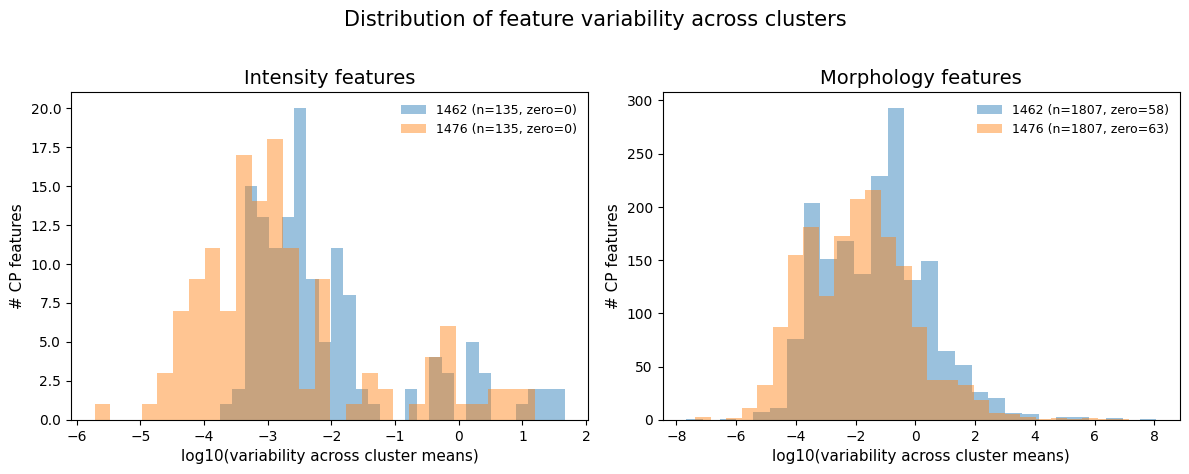

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# 0) Output folder
# ------------------------------------------------------------------
FIG9_DIR = Path(r"Z:\1 BIS\Shared folders\Jan\Artikel in opbouw\Nikita pseudotime analysis\3. main figure folder\Figure 9 morphological variability")

# ------------------------------------------------------------------
# 1) Rebuild FULL variability summaries
#    (not the selected 5 + 5 features, but all available features)
# ------------------------------------------------------------------
results_intensity_full = {
    surface_name: build_surface_summary(
        clustered_tables[surface_name],
        surface_name
    )
    for surface_name in ["1462", "1476"]
}

results_morphology_full = {
    surface_name: build_surface_summary_nonint(
        clustered_tables[surface_name],
        surface_name
    )
    for surface_name in ["1462", "1476"]
}

# ------------------------------------------------------------------
# 2) Helper: convert variability dict to a plotting table
# ------------------------------------------------------------------
def variability_results_to_df(results_dict, feature_group_name):
    frames = []

    for surface_name, summary in results_dict.items():
        s = summary["variability_all"].copy().astype(float)

        df = pd.DataFrame({
            "surface": surface_name,
            "feature_group": feature_group_name,
            "metric_name": s.index,
            "variability_std": s.values,
        })
        df["is_zero"] = np.isclose(df["variability_std"], 0.0)
        df["log10_variability_std"] = np.where(
            df["variability_std"] > 0,
            np.log10(df["variability_std"]),
            np.nan
        )
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

variability_df_intensity = variability_results_to_df(results_intensity_full, "Intensity")
variability_df_morphology = variability_results_to_df(results_morphology_full, "Morphology")

# Optional export of the full table behind the plot
variability_df_all = pd.concat([variability_df_intensity, variability_df_morphology], ignore_index=True)
variability_df_all.to_csv(FIG9_DIR / "all_feature_variability_distributions.csv", index=False)

# ------------------------------------------------------------------
# 3) Plot function
# ------------------------------------------------------------------
def plot_variability_distribution_panels(
    df_intensity,
    df_morphology,
    bins=28,
    figsize=(12, 4.6),
    facecolor="white",
    save_path=None,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize, facecolor=facecolor)
    for ax in axes:
        ax.set_facecolor(facecolor)

    panel_specs = [
        ("Intensity features", df_intensity, axes[0]),
        ("Morphology features", df_morphology, axes[1]),
    ]

    for title, df_panel, ax in panel_specs:
        summary_lines = []

        for surface_name in ["1462", "1476"]:
            sub = df_panel[df_panel["surface"] == surface_name].copy()

            positive_vals = sub.loc[~sub["is_zero"], "log10_variability_std"].dropna().to_numpy()
            zero_count = int(sub["is_zero"].sum())
            total_count = len(sub)

            if len(positive_vals) > 0:
                ax.hist(
                    positive_vals,
                    bins=bins,
                    histtype="stepfilled",
                    alpha=0.45,
                    linewidth=1.2,
                    label=f"{surface_name} (n={total_count}, zero={zero_count})"
                )

            summary_lines.append(
                f"{surface_name}: n={total_count}, zero={zero_count}, non-zero={total_count - zero_count}"
            )

        ax.set_title(title, fontsize=14)
        ax.set_xlabel("log10(variability across cluster means)", fontsize=11)
        ax.set_ylabel("# CP features", fontsize=11)
        ax.legend(frameon=False, fontsize=9)

#

    fig.suptitle("Distribution of feature variability across clusters", fontsize=15, y=1.02)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

    plt.show()
    return fig

# ------------------------------------------------------------------
# 4) Make the figure
# ------------------------------------------------------------------
fig = plot_variability_distribution_panels(
    variability_df_intensity,
    variability_df_morphology,
    bins=28,
    figsize=(12, 4.6),
    save_path=FIG9_DIR / "figure 9 variability distributions.png"
)